# 05. Compare mutational spectra

This notebook builds DB-weighted mutational spectra for groups prepared in `03_prepare_spectrum_groups.ipynb` and weighted in `04_add_spectrum_weights.ipynb`.

The input table is:

```text
../results/spectrum_groups/spectrum_groups_with_weights_T95.tsv
```

The key weight is:

```text
combined_db_spectrum_weight
```

It is calculated in the previous step as:

```text
combined_db_spectrum_weight =
    max(gnomAD_count + Helix_count, 1)
    /
    ((gnomAD_total + Helix_total) × ref_base_count)
```

Here `ref_base_count` is the number of reference nucleotides of the same type as the mutated base. For example, `A>G` is normalized by the number of `A` nucleotides, and `C>T` is normalized by the number of `C` nucleotides.

In this notebook we do **not** divide by `ref_base_count` again. We only sum the already normalized weights inside each group.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)

In [2]:
# ============================================================
# Paths
# ============================================================

INPUT_PATH = Path("../results/spectrum_groups/spectrum_groups_with_weights_T95.tsv")

OUTPUT_DIR = Path("../results/mutation_spectra")
FIGURE_DIR = Path("../results/figures/mutation_spectra_T95")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SPECTRUM_OUTPUT = OUTPUT_DIR / "spectrum_weighted_frequencies_T95.tsv"

WEIGHT_COL = "combined_db_spectrum_weight"
GROUP_COL = "spectrum_group_primary_T95"

substitution_order_12 = [
    "A>C", "A>G", "A>T",
    "C>A", "C>G", "C>T",
    "G>A", "G>C", "G>T",
    "T>A", "T>C", "T>G",
]

## Load spectrum-group table

At this stage each row is one possible mtDNA SNV. The table already contains the group assignment from Isolation Forest and the population-derived spectrum weight from gnomAD + Helix.

In [3]:
df = pd.read_csv(INPUT_PATH, sep="\t", low_memory=False)

work = df.copy()

if "substitution_type_12" not in work.columns:
    work["substitution_type_12"] = (
        work["reference"].astype(str).str.upper()
        + ">"
        + work["alternate"].astype(str).str.upper()
    )

if "is_valid_snv_substitution" in work.columns:
    work = work[work["is_valid_snv_substitution"] == True].copy()

work = work[work[GROUP_COL] != "exclude"].copy()

work[WEIGHT_COL] = pd.to_numeric(work[WEIGHT_COL], errors="coerce").fillna(0.0)

print("Input shape:", df.shape)
print("Analysis table shape:", work.shape)

print("\nGroups:")
print(work[GROUP_COL].value_counts(dropna=False))

print("\nWeight summary:")
print(work[WEIGHT_COL].describe())

Input shape: (49704, 56)
Analysis table shape: (49564, 56)

Groups:
spectrum_group_primary_T95
unlabeled_out_of_neutral_domain_T95    26937
expanded_neutral_like_T95              22627
Name: count, dtype: int64

Weight summary:
count    4.956400e+04
mean     1.376064e-07
std      3.116026e-06
min      7.646590e-10
25%      7.731652e-10
50%      9.676840e-10
75%      1.826509e-09
max      2.839619e-04
Name: combined_db_spectrum_weight, dtype: float64


## Calculate weighted mutational spectrum

For each group `g` and substitution type `t`:

```text
weighted_sum(g, t) =
    Σ combined_db_spectrum_weight_i
```

where the sum is taken over all variants `i` that belong to group `g` and substitution type `t`.

Then we normalize the weights inside each group:

```text
weighted_frequency(g, t) =
    weighted_sum(g, t) / Σ weighted_sum(g, all substitution types)
```

This gives a 12-component DB-weighted mutational spectrum for each group.

In [4]:
def compute_weighted_spectrum(data, group_col, weight_col):
    spectrum = (
        data
        .groupby([group_col, "substitution_type_12"], as_index=False)
        .agg(
            n_variants=("variant_id", "count"),
            weighted_sum=(weight_col, "sum"),
        )
        .rename(columns={
            group_col: "group_name",
            "substitution_type_12": "substitution_type",
        })
    )

    all_groups = sorted(spectrum["group_name"].dropna().unique())

    complete_index = pd.MultiIndex.from_product(
        [all_groups, substitution_order_12],
        names=["group_name", "substitution_type"],
    )

    spectrum = (
        spectrum
        .set_index(["group_name", "substitution_type"])
        .reindex(complete_index)
        .reset_index()
    )

    spectrum["n_variants"] = spectrum["n_variants"].fillna(0).astype(int)
    spectrum["weighted_sum"] = spectrum["weighted_sum"].fillna(0.0)

    spectrum["total_weight"] = (
        spectrum
        .groupby("group_name")["weighted_sum"]
        .transform("sum")
    )

    spectrum["weighted_frequency"] = (
        spectrum["weighted_sum"] / spectrum["total_weight"]
    )

    spectrum.insert(0, "group_col", group_col)
    spectrum["weight_col"] = weight_col

    return spectrum


spectrum = compute_weighted_spectrum(
    data=work,
    group_col=GROUP_COL,
    weight_col=WEIGHT_COL,
)

spectrum.to_csv(SPECTRUM_OUTPUT, sep="\t", index=False)

print("Saved:", SPECTRUM_OUTPUT)
display(spectrum.head(24))

Saved: ..\results\mutation_spectra\spectrum_weighted_frequencies_T95.tsv


,group_col,group_name,substitution_type,n_variants,weighted_sum,total_weight,weighted_frequency,weight_col
0,spectrum_group_primary_T95,expanded_neutral_like_T95,A>C,2365,0.000019,0.005512,0.003494,combined_db_spectrum_weight
1,spectrum_group_primary_T95,expanded_neutral_like_T95,A>G,3024,0.001312,0.005512,0.238047,combined_db_spectrum_weight
2,spectrum_group_primary_T95,expanded_neutral_like_T95,A>T,2400,0.000017,0.005512,0.003031,combined_db_spectrum_weight
3,spectrum_group_primary_T95,expanded_neutral_like_T95,C>A,2650,0.000063,0.005512,0.011511,combined_db_spectrum_weight
4,spectrum_group_primary_T95,expanded_neutral_like_T95,C>G,2619,0.000005,0.005512,0.000929,combined_db_spectrum_weight
5,spectrum_group_primary_T95,expanded_neutral_like_T95,C>T,3248,0.000744,0.005512,0.135074,combined_db_spectrum_weight
6,spectrum_group_primary_T95,expanded_neutral_like_T95,G>A,794,0.002055,0.005512,0.372843,combined_db_spectrum_weight
7,spectrum_group_primary_T95,expanded_neutral_like_T95,G>C,604,0.000027,0.005512,0.004874,combined_db_spectrum_weight
8,spectrum_group_primary_T95,expanded_neutral_like_T95,G>T,582,0.000010,0.005512,0.001880,combined_db_spectrum_weight
9,spectrum_group_primary_T95,expanded_neutral_like_T95,T>A,1299,0.000017,0.005512,0.003165,combined_db_spectrum_weight


## Plot functions

The plots below use `weighted_frequency` as the spectrum value. This is the final DB-weighted spectrum.

In [ ]:
group_label_map = {
    "expanded_neutral_like_T95": "Expanded neutral-like",
    "strict_expanded_neutral_like_T95": "Strict expanded neutral-like",
    "unlabeled_out_of_neutral_domain_T95": "Out-of-neutral-domain",
    "known_neutral_reference": "Known neutral reference",
    "article_pathogenic_posthoc": "Article pathogenic post-hoc",
    "disease_suspected_posthoc": "Disease suspected post-hoc",
    "unlabeled_neutral_like_T95": "Unlabeled neutral-like",
}


def safe_filename(text):
    return (
        str(text)
        .replace("/", "_")
        .replace(" ", "_")
        .replace(">", "to")
        .replace(":", "_")
    )


def plot_single_spectrum(spectrum_df, group_name, output_dir=FIGURE_DIR):
    plot_df = (
        spectrum_df[spectrum_df["group_name"] == group_name]
        .set_index("substitution_type")
        .reindex(substitution_order_12)
        .reset_index()
    )

    x = np.arange(len(substitution_order_12))
    y = plot_df["weighted_frequency"].values

    label = group_label_map.get(group_name, group_name)
    n_variants = int(plot_df["n_variants"].sum())

    plt.figure(figsize=(10, 5))
    plt.bar(x, y)
    plt.xticks(x, substitution_order_12, rotation=45, ha="right")
    plt.ylabel("DB-weighted spectrum frequency")
    plt.xlabel("Substitution type")
    plt.title(f"{label} n={n_variants}")
    plt.tight_layout()

    output_path = output_dir / f"spectrum_{safe_filename(group_name)}.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    return output_path


def plot_two_group_comparison(spectrum_df, group_1, group_2, output_dir=FIGURE_DIR):
    df1 = (
        spectrum_df[spectrum_df["group_name"] == group_1]
        .set_index("substitution_type")
        .reindex(substitution_order_12)
        .reset_index()
    )

    df2 = (
        spectrum_df[spectrum_df["group_name"] == group_2]
        .set_index("substitution_type")
        .reindex(substitution_order_12)
        .reset_index()
    )

    x = np.arange(len(substitution_order_12))
    width = 0.4

    label_1 = group_label_map.get(group_1, group_1)
    label_2 = group_label_map.get(group_2, group_2)

    plt.figure(figsize=(11, 5))
    plt.bar(x - width / 2, df1["weighted_frequency"].values, width=width, label=label_1)
    plt.bar(x + width / 2, df2["weighted_frequency"].values, width=width, label=label_2)
    plt.xticks(x, substitution_order_12, rotation=45, ha="right")
    plt.ylabel("DB-weighted spectrum frequency")
    plt.xlabel("Substitution type")
    plt.title("DB-weighted mutational spectrum comparison")
    plt.legend()
    plt.tight_layout()

    output_path = output_dir / f"spectrum_comparison_{safe_filename(group_1)}_vs_{safe_filename(group_2)}.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    return output_path


def plot_spectrum_difference(spectrum_df, reference_group, comparison_group, output_dir=FIGURE_DIR):
    ref = (
        spectrum_df[spectrum_df["group_name"] == reference_group]
        .set_index("substitution_type")
        .reindex(substitution_order_12)
        .reset_index()
    )

    comp = (
        spectrum_df[spectrum_df["group_name"] == comparison_group]
        .set_index("substitution_type")
        .reindex(substitution_order_12)
        .reset_index()
    )

    diff = comp["weighted_frequency"].values - ref["weighted_frequency"].values

    x = np.arange(len(substitution_order_12))

    label_ref = group_label_map.get(reference_group, reference_group)
    label_comp = group_label_map.get(comparison_group, comparison_group)

    plt.figure(figsize=(10, 5))
    plt.bar(x, diff)
    plt.axhline(0, linewidth=1)
    plt.xticks(x, substitution_order_12, rotation=45, ha="right")
    plt.ylabel("Difference in DB-weighted frequency")
    plt.xlabel("Substitution type")
    plt.title(f"{label_comp} minus {label_ref}")
    plt.tight_layout()

    output_path = output_dir / f"spectrum_difference_{safe_filename(comparison_group)}_minus_{safe_filename(reference_group)}.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    return output_path

## Main plots

The main comparison is between the expanded neutral-like group and variants outside the neutral domain.

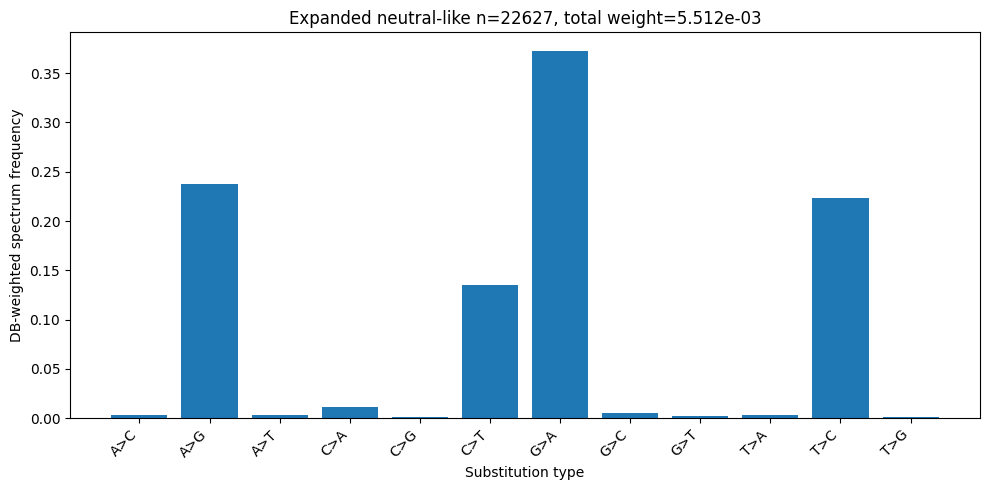

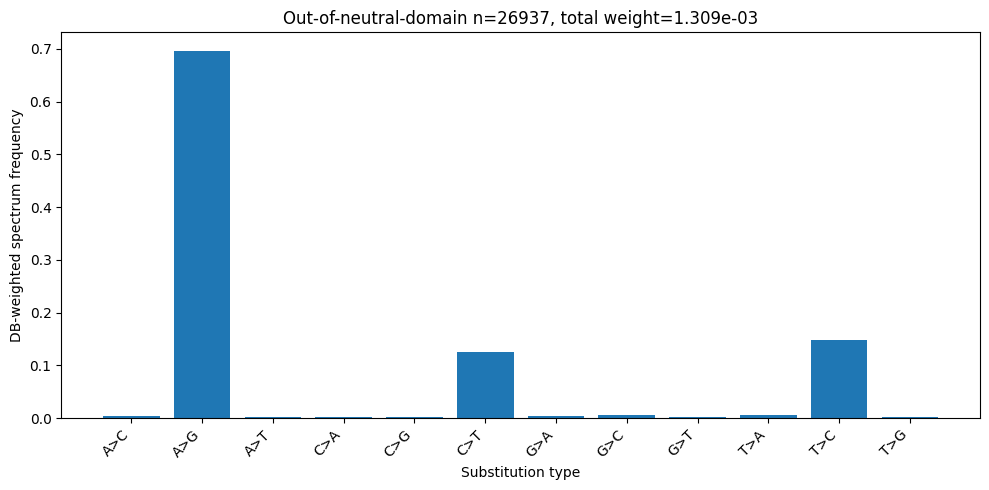

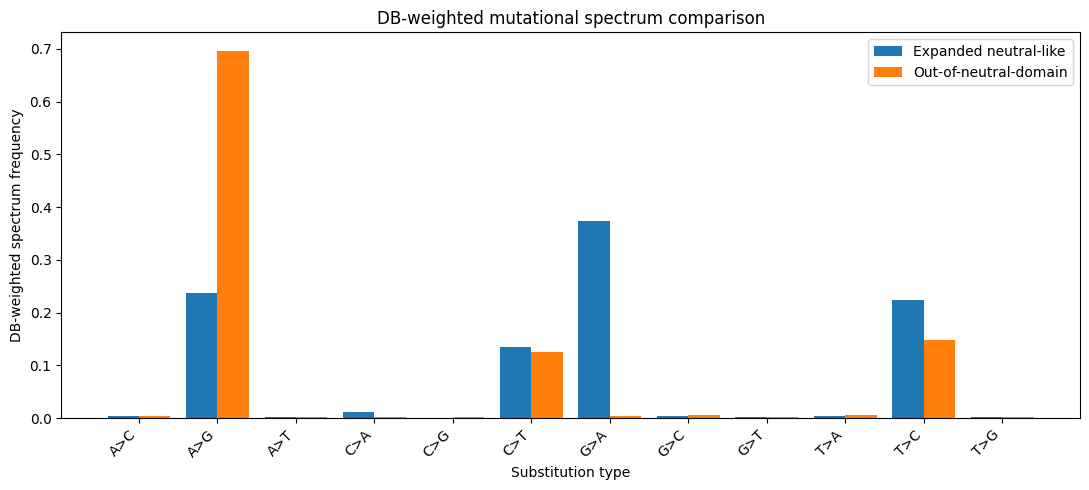

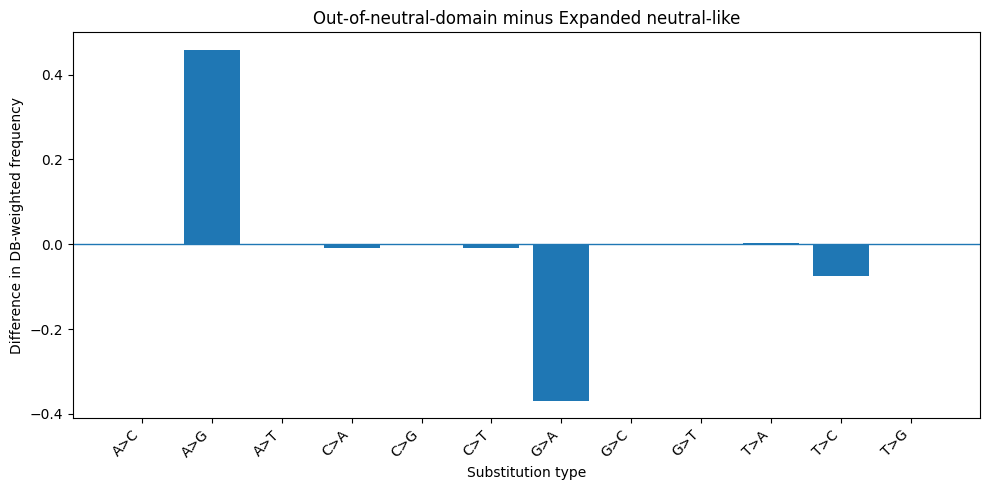

Figures saved to: ..\results\figures\mutation_spectra_T95


In [8]:
neutral_like_group = "expanded_neutral_like_T95"
out_of_domain_group = "unlabeled_out_of_neutral_domain_T95"

plot_single_spectrum(spectrum, neutral_like_group)
plot_single_spectrum(spectrum, out_of_domain_group)

plot_two_group_comparison(
    spectrum,
    group_1=neutral_like_group,
    group_2=out_of_domain_group,
)

plot_spectrum_difference(
    spectrum,
    reference_group=neutral_like_group,
    comparison_group=out_of_domain_group,
)

print("Figures saved to:", FIGURE_DIR)